In [83]:
import pandas as pd

file_path="data_scaling_skewed_data.csv"

df=pd.read_csv(file_path)

In [69]:
df.head()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
0,1,4.79,25,68.22,26401.83,5.13,68.46
1,2,2.99,25,72.62,29899.43,10.14,58.53
2,3,2.76,24,87.15,84956.82,6.63,50.72
3,4,2.76,20,87.14,15797.16,0.99,72.44
4,5,9.30,18,87.15,44019.48,2.10,60.92


In [84]:
df.shape

(100, 7)

In [70]:
df.describe()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
count,100.000000,100.000000,100.000000,97.000000,100.000000,98.000000,100.000000
mean,50.500000,3.838400,21.670000,81.819588,40416.447600,2.971837,67.884100
std,29.011492,2.453124,2.395513,9.957090,37941.665524,2.842141,11.554282
min,1.000000,0.430000,18.000000,49.590000,3977.840000,0.050000,40.340000
25%,25.750000,2.180000,20.000000,75.380000,15954.600000,0.765000,59.675000
50%,50.500000,3.395000,22.000000,82.640000,27459.915000,2.165000,67.640000
75%,75.250000,4.810000,24.000000,88.620000,47944.172500,3.900000,76.387500
max,100.000000,14.600000,25.000000,100.000000,193072.810000,13.700000,94.900000


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            100 non-null    int64  
 1   Study_Hours           100 non-null    float64
 2   Age                   100 non-null    int64  
 3   Attendance            97 non-null     float64
 4   Family_Income         100 non-null    float64
 5   Internet_Usage_Hours  98 non-null     float64
 6   Exam_Score            100 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 5.6 KB


In [72]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              3
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [73]:
df.isnull().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              3
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [75]:
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].median())


In [76]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              0
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [77]:
df["Internet_Usage_Hours"]=df["Internet_Usage_Hours"].fillna(df["Internet_Usage_Hours"].mean())

In [78]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              0
Family_Income           0
Internet_Usage_Hours    0
Exam_Score              0
dtype: int64

In [85]:
df.duplicated().sum()

np.int64(0)

In [86]:
df[df.duplicated()]

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score


In [87]:
df = df.drop_duplicates()

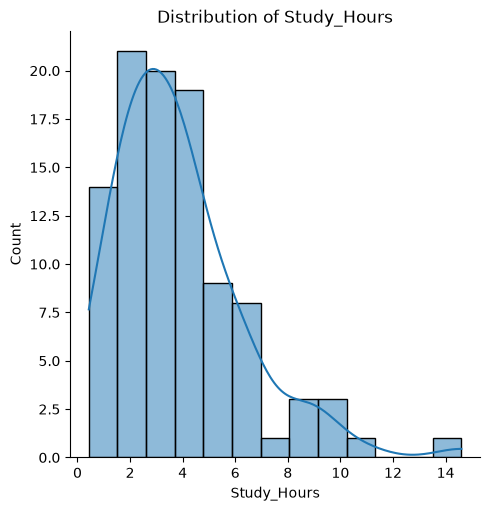

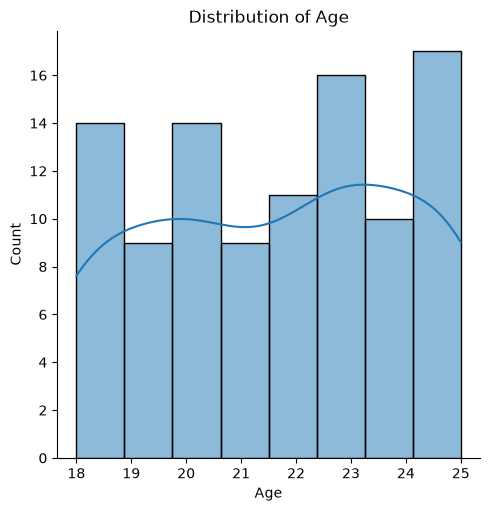

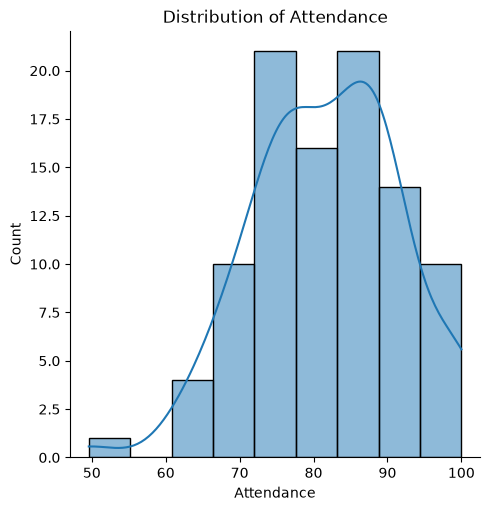

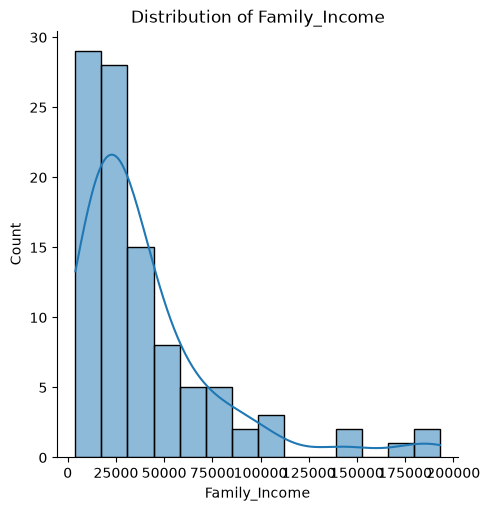

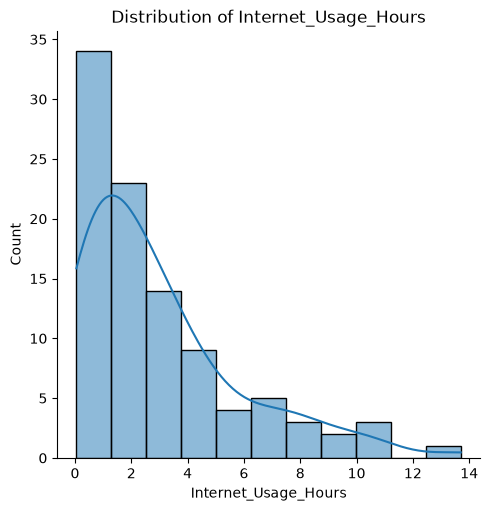

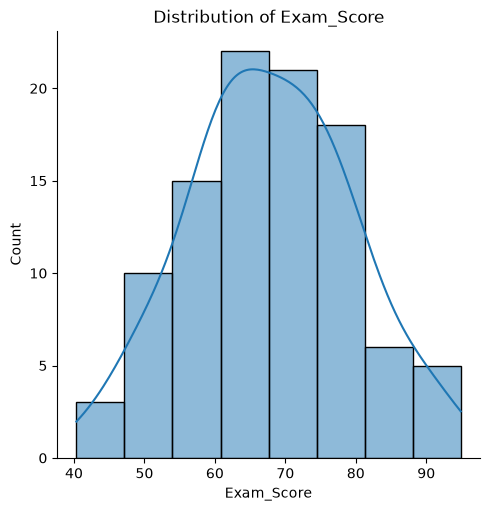

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = [
    "Study_Hours",
    "Age",
    "Attendance",
    "Family_Income",
    "Internet_Usage_Hours",
    "Exam_Score"
]

for col in numerical_columns:
    sns.displot(x=df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [89]:
df[numerical_columns].skew()

Study_Hours             1.466644
Age                    -0.104205
Attendance             -0.271046
Family_Income           2.242351
Internet_Usage_Hours    1.474339
Exam_Score              0.038566
dtype: float64

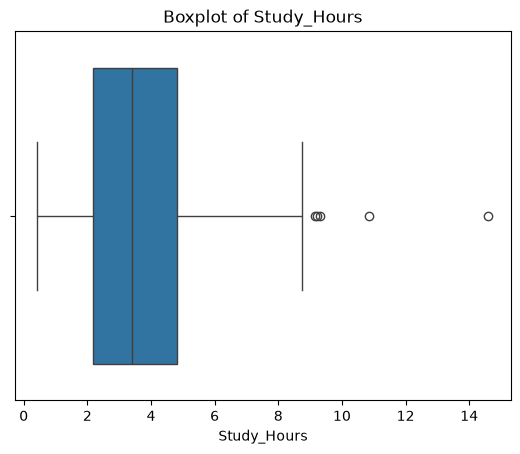

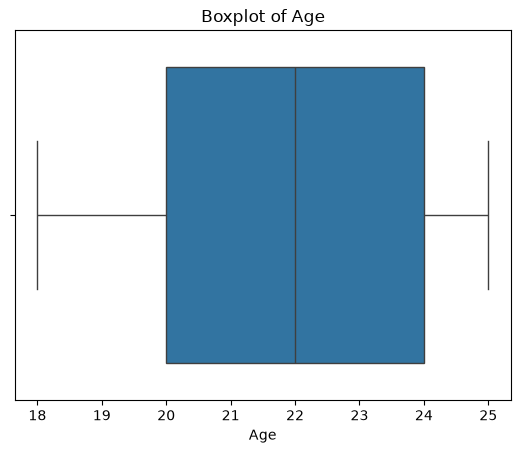

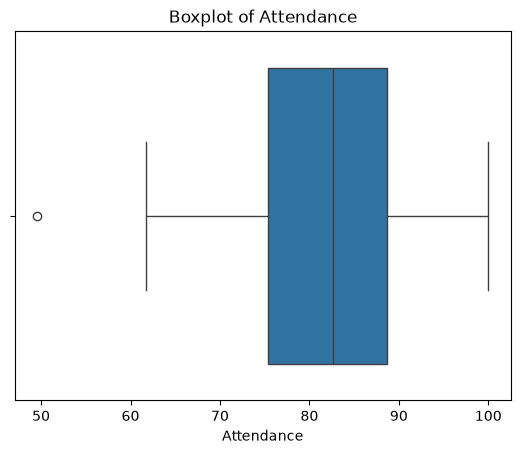

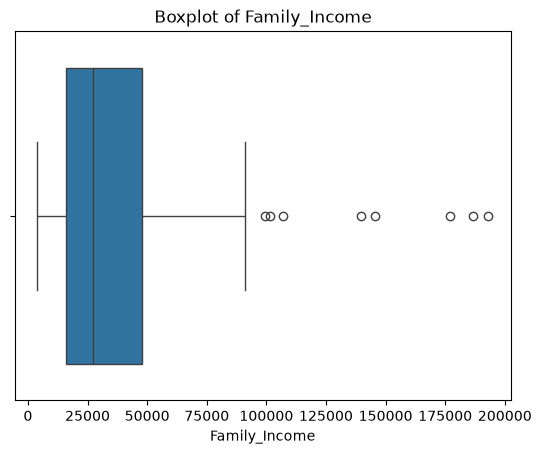

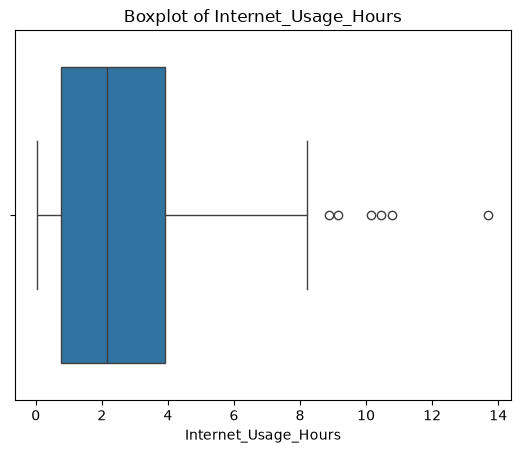

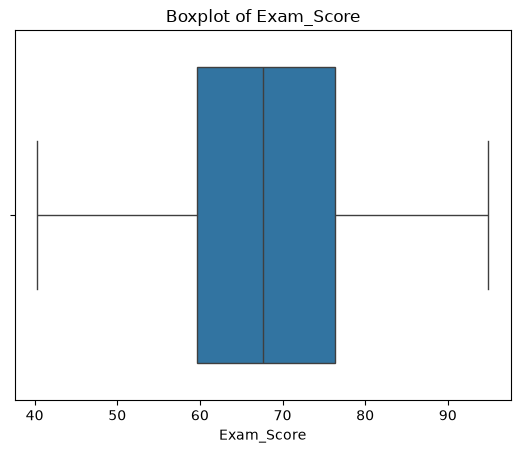

In [90]:
for col in numerical_columns:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [93]:
corr = df[numerical_columns].corr()

corr

,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
Study_Hours,1.000000,-0.035483,-0.088588,0.057223,-0.020783,0.069318
Age,-0.035483,1.000000,0.025923,0.054697,0.025997,0.012881
Attendance,-0.088588,0.025923,1.000000,-0.005532,-0.069543,0.019875
Family_Income,0.057223,0.054697,-0.005532,1.000000,-0.005486,-0.027481
Internet_Usage_Hours,-0.020783,0.025997,-0.069543,-0.005486,1.000000,0.109160
Exam_Score,0.069318,0.012881,0.019875,-0.027481,0.109160,1.000000


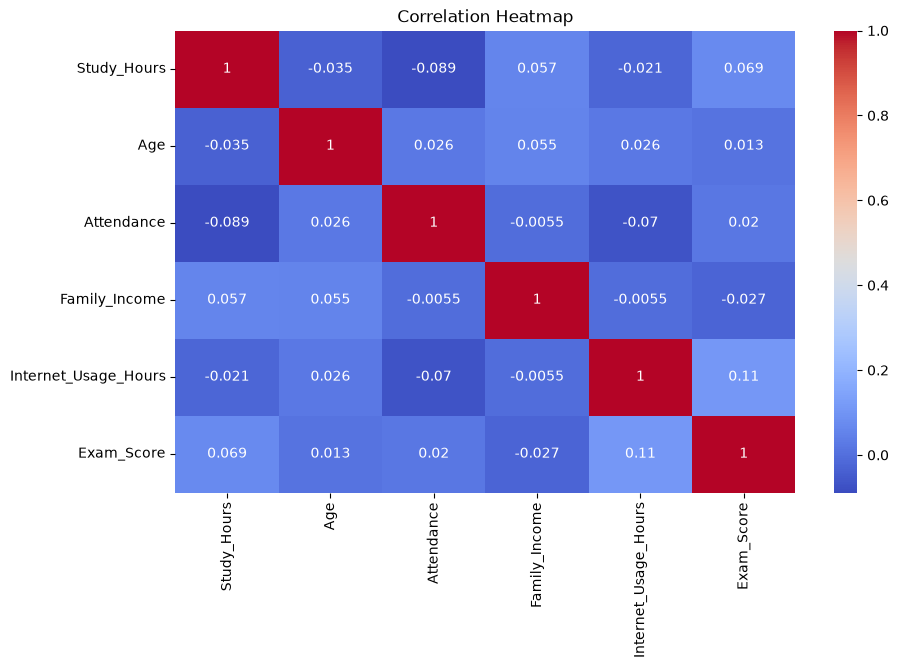

In [96]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df = df.drop("Student_ID", axis=1)

In [98]:
df.head()

,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
0,4.79,25,68.22,26401.83,5.13,68.46
1,2.99,25,72.62,29899.43,10.14,58.53
2,2.76,24,87.15,84956.82,6.63,50.72
3,2.76,20,87.14,15797.16,0.99,72.44
4,9.30,18,87.15,44019.48,2.10,60.92


In [99]:
X = df.drop("Exam_Score", axis=1)

In [100]:
y = df["Exam_Score"]

In [101]:
X.head()

,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours
0,4.79,25,68.22,26401.83,5.13
1,2.99,25,72.62,29899.43,10.14
2,2.76,24,87.15,84956.82,6.63
3,2.76,20,87.14,15797.16,0.99
4,9.30,18,87.15,44019.48,2.10


In [102]:
y.head()

0    68.46
1    58.53
2    50.72
3    72.44
4    60.92
Name: Exam_Score, dtype: float64

In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled[:5]

array([[ 0.38986776,  1.39710169, -1.37291472, -0.37123359,  0.76324829],
       [-0.34758702,  1.39710169, -0.92872296, -0.27858557,  2.53506695],
       [-0.44181735,  0.97755163,  0.53811938,  1.17983114,  1.29373292],
       [-0.44181735, -0.70064859,  0.53710985, -0.65214098, -0.70088928],
       [ 2.23760169, -1.5397487 ,  0.53811938,  0.09544082, -0.30833066]])

In [107]:
from sklearn.preprocessing import PowerTransformer

power_transformer = PowerTransformer(method="yeo-johnson")

In [108]:
skewed_columns = [
    "Study_Hours",
    "Family_Income",
    "Internet_Usage_Hours"
]

X[skewed_columns] = power_transformer.fit_transform(
    X[skewed_columns]
)

In [109]:
X[skewed_columns].skew()

Study_Hours            -0.000214
Family_Income           0.005131
Internet_Usage_Hours    0.045666
dtype: float64

In [110]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, StandardScaler


skewed_columns = [
    "Study_Hours",
    "Family_Income",
    "Internet_Usage_Hours"
]

normal_columns = [
    "Age",
    "Attendance"
]



In [111]:
preprocessor = ColumnTransformer(
    transformers=[
        ("skewed", PowerTransformer(method="yeo-johnson"), skewed_columns),
        ("normal", StandardScaler(), normal_columns)
    ]
)
X_processed = preprocessor.fit_transform(X)


In [112]:
X_processed

array([[ 6.09732216e-01, -7.99807719e-02,  1.00827430e+00,
         1.39710169e+00, -1.37291472e+00],
       [-1.64608235e-01,  7.68310980e-02,  1.74284627e+00,
         1.39710169e+00, -9.28722960e-01],
       [-2.87496975e-01,  1.31670350e+00,  1.28891856e+00,
         9.77551630e-01,  5.38119376e-01],
       [-2.87496975e-01, -7.49582572e-01, -6.83806017e-01,
        -7.00648593e-01,  5.37109850e-01],
       [ 1.81761470e+00,  5.51404161e-01,  3.78139407e-02,
        -1.53974870e+00,  5.38119376e-01],
       [ 9.24173399e-01, -2.88833791e-01, -1.20972148e+00,
         1.39710169e+00,  1.83536122e+00],
       [-5.82246020e-01, -3.06844348e-01,  1.80667583e+00,
        -1.53974870e+00,  5.94652873e-01],
       [ 6.63133474e-01,  1.13388635e+00,  5.09566766e-01,
         1.39710169e+00,             nan],
       [ 3.03938057e-01,  8.48866967e-01, -7.54536959e-01,
        -2.81098537e-01,  9.81301610e-01],
       [-2.27143739e+00,  8.36293766e-01,  7.06330072e-01,
        -7.00648593e-01

In [113]:
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("skewed", PowerTransformer(method="yeo-johnson"), skewed_columns),
        ("normal", StandardScaler(), normal_columns)
    ]
)

In [114]:
pipeline = Pipeline([
    ("preprocessor", preprocessor)
])

In [115]:
X_processed = pipeline.fit_transform(X)

In [120]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Study_Hours','Age','Attendance','Family_Income','Internet_Usage_Hours']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed', ...), ('normal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concate